# Laboratorio 5 - Reinforcement Learning
### José Antonio Mérida Castejón - Carné 201105

Este Notebook corresponde al Task 2 de la tarea Laboratorio 5, consiste en la implementación de un agente que navega el entorno "Frozen Lake" (tal como el lab anterior) utilizando Gymnasium y Q-Learning.

## Task 2.1 - Instalación y Ambiente
En este inciso, inicializamos el entorno utilizando Gymnasium y exploramos para conocer con lo que estaremos trabajando el resto del laboratorio. Primero, vamos a inicializar el entorno `FrozenLake-v1` con el parámetro `is_slippery=True` y `render_mode=rgb_array`.

In [80]:
import gymnasium as gym
# Cargar entorno
env = gym.make("FrozenLake-v1", is_slippery=True, render_mode="rgb_array")

# Inicializar entorno
env.reset()

(0, {'prob': 1})

Luego de haber cargado en entorno, podemos explorarlo un poco. Al haber trabajado un entorno similar en el laboratorio pasado, ya conocemos un poco sobre el ambiente. Vamos a empezar imprimiento el mapa, luego la cantidad de estados y acciones y por último las transiciones.

In [81]:
print("Mapa:")
print(env.unwrapped.desc)

print(f"\nEstados:  {env.observation_space.n}")
print(f"Acciones: {env.action_space.n}")

print("\nTransiciones del Estado 0:")
for action, transitions in env.unwrapped.P[0].items():
    print(f"  Acción {action}: {transitions}")

Mapa:
[[b'S' b'F' b'F' b'F']
 [b'F' b'H' b'F' b'H']
 [b'F' b'F' b'F' b'H']
 [b'H' b'F' b'F' b'G']]

Estados:  16
Acciones: 4

Transiciones del Estado 0:
  Acción 0: [(0.33333333333333337, 0, 0, False), (0.3333333333333333, 0, 0, False), (0.33333333333333337, 4, 0, False)]
  Acción 1: [(0.33333333333333337, 0, 0, False), (0.3333333333333333, 4, 0, False), (0.33333333333333337, 1, 0, False)]
  Acción 2: [(0.33333333333333337, 4, 0, False), (0.3333333333333333, 1, 0, False), (0.33333333333333337, 0, 0, False)]
  Acción 3: [(0.33333333333333337, 1, 0, False), (0.3333333333333333, 0, 0, False), (0.33333333333333337, 0, 0, False)]


Podemos ver que contamos con 16 estados y 4 acciones, esto es consistente con el diseño del laboratorio anterior dónde definimos una matriz de 4x4 sobre la cual navegar. Adicionalmente, las acciones son las mismas, dónde al realizar un movimiento es posible resbalarse y caer en un tile hacia la izquierda o derecha de la dirección dónde nos queremos dirigir con 1/3 de probabilidad cada uno. En cuanto al mapa, tenemos una identificación idéntica al entorno que definimos en el laboratorio pasado dónde contamos con tiles F (de Frozen), H (de Hole), S (de Start) y G (de goal). También podemos comprobar renderizar el mapa, para confirmar.

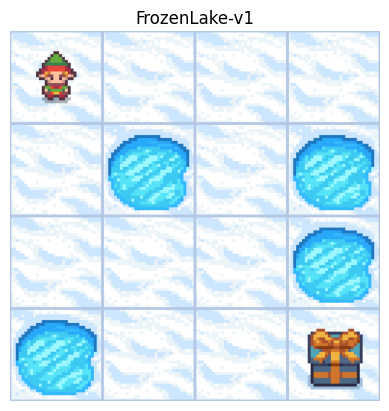

In [82]:
import matplotlib.pyplot as plt

frame = env.render()
plt.imshow(frame)
plt.axis("off")
plt.title("FrozenLake-v1")
plt.show()

Ya con el mapa graficado, podemos concluir que el entorno ha sido cargado exitosamente y que conocemos la manera cómo funciona.

## Task 2.2- Q-Learning

Implementamos Q-Learning en una sola función que recibe los hiperparámetros y el ambiente como parámetros. Durante el entrenamiento, se sigue la política **Epsilon-Greedy** para balancear exploración y explotación, reduciendo epsilon gradualmente. Adicionalmente, permitimos que se pueda tomar Q como parámetro (default=None) para poder realizar la evaluación del Task 2.3 y también guardamos el historial de episodios.

Para la evaluación (Task 2.3), se reutiliza la misma función con `alpha=0` y `epsilon=0`, desactivando el aprendizaje y la exploración para evaluar la política aprendida de forma puramente codiciosa.

$$Q(s,a) \leftarrow Q(s,a) + \alpha \left[ R + \gamma \max Q(s',a') - Q(s,a) \right]$$

In [83]:
import numpy as np

# Definición de función
def q_learning(env, alpha=0.8, Q=None, gamma=0.95, epsilon=1.0, eps_min=0.01, eps_decay=0.999, episodes=10_000):
    # Inicialización de matriz de ceros, si no es pasada como parámetro
    if Q is None:
        Q = np.zeros((env.observation_space.n, env.action_space.n))
    # Historial de episodios (reward, pasos, victoria) para análisis posterior
    history = []

    # Bucle de entrenamiento
    for ep in range(episodes):
        # Reiniciar entorno y re establecer variables
        state, _ = env.reset()
        total_reward = 0
        terminated = False
        # Pasos del episodio actual
        steps = []

        # Mientras no termine el juego
        while not terminated:
            # Elegir usando Epsilon-Greedy
            if np.random.rand() < epsilon:
                # Explorar con Epsilon de probabilidad
                action = env.action_space.sample()
            else:
                # Explotar con 1 - Epsilon de probabilidad
                action = np.argmax(Q[state])

            # Ejecutar acción y observar siguiente estado, reward y si se termina el episodio (terminated o truncated)
            next_state, reward, terminated, truncated, _ = env.step(action)
            terminated = terminated or truncated

            # Actualizar, Q(s,a) <- Q(sa) + alpha [R + gamma * max(Q(s', a') - Q(s,a)))]
            Q[state, action] += alpha * (reward + gamma * np.max(Q[next_state]) - Q[state, action])

            # Actualizar estado y reward
            state = next_state
            total_reward += reward
            # Guardar paso en historial
            steps.append((state, action, next_state, reward))

        # Guardar historial del episodio y actualizar epsilon (necesario por el decay)
        history.append({"episode": ep, "reward": total_reward, "steps": steps, "won": total_reward > 0})
        epsilon = max(eps_min, epsilon * eps_decay)

    return Q, history

### Entrenamiento

In [84]:
# Entrenamiento
Q, train_history = q_learning(env)
print(f"Tasa de éxito entrenamiento (últimos 1000 ep): {np.mean([ep['won'] for ep in train_history[-1000:]]):.2%}")

# Evaluación — misma función pero pasando Q entrenada, alpha=0 y epsilon=0 (sin aprendizaje ni exploración)
_, eval_history = q_learning(env, Q=Q, alpha=0, epsilon=0, eps_min=0, eps_decay=1, episodes=10)

Tasa de éxito entrenamiento (últimos 1000 ep): 53.30%


## Task 2.3 - Evaluación de la Política Aprendida

Con la tabla Q entrenada, evaluamos el agente en 10 episodios de prueba sin exploración (ϵ=0, puramente codicioso). Reportamos el Win Rate y visualizamos un episodio exitoso.

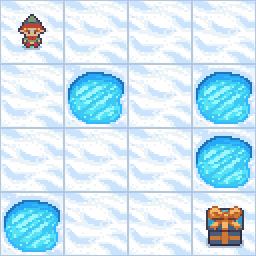

In [85]:
from pathlib import Path
from gymnasium.wrappers import RecordVideo
from IPython.display import Image
import imageio

# Envolver el entorno con grabación de video
env_rec = RecordVideo(
    gym.make("FrozenLake-v1", is_slippery=True, render_mode="rgb_array"),
    video_folder="./gym-results",
    episode_trigger=lambda e: True  # grabar todos los episodios
)

# Correr un episodio con la política aprendida
state, _ = env_rec.reset()
terminated = False
while not terminated:
    action = np.argmax(Q[state])
    state, reward, terminated, truncated, _ = env_rec.step(action)
    terminated = terminated or truncated
env_rec.close()

# Convertir mp4 a gif y mostrar inline
mp4_path = str(sorted(Path("./gym-results").glob("*.mp4"))[-1])
gif_path = "./gym-results/episode.gif"

reader = imageio.get_reader(mp4_path)
frames = [frame for frame in reader]
imageio.mimsave(gif_path, frames, fps=reader.get_meta_data()['fps'], loop=0)

Image(gif_path)

![FrozenLake](gym-results/episode.gif)